Version of domain-boundary element method with operator form

The matrix multiplication L@u is computed on-the-fly, so that the dense matrix does not need to be stored.

This is however very slow even for the forward multiplication. This may be remedied by off-loading the work to C or performing matrix multiplication by blocks instead of row-wise for improved vectorization.

For matrix inverse, consider MINRES with Jacobi preconditioner (effective due to the singular part being nearly dominant).

In [87]:
# # %pip install --upgrade pip
# %pip install gmsh
# %pip install meshio --user

In [88]:
import gmsh
import numpy as np
import scipy.optimize
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib


In [89]:
show_gmsh_window = False
msh_file_name = "shell_mesh_operator.msh"

In [90]:
gmsh.initialize()

dx = 0.2
# Annulus inner and outer radius
a = .25
b = 1.5

points = [
  # Bounding box vertices
  gmsh.model.geo.addPoint(-0.5, -0.5, 0, dx),
  gmsh.model.geo.addPoint(0.5,  -0.5, 0, dx),
  gmsh.model.geo.addPoint(0.5,  0.5,  0, dx),
  gmsh.model.geo.addPoint(-0.5, 0.5,  0, dx),
  # Inner circle points
  gmsh.model.geo.addPoint(0.0, 0, 0, dx),
  gmsh.model.geo.addPoint(a, 0, 0, dx),
  gmsh.model.geo.addPoint(-a, 0, 0, dx),
  # Outer circle points
  gmsh.model.geo.addPoint(0.0, 0.0, 0, dx),
  gmsh.model.geo.addPoint(b, 0.0, 0, dx),
  gmsh.model.geo.addPoint(-b, 0.0, 0, dx),
]
lines = [
  # Box lines
  # gmsh.model.geo.add_line(points[0], points[1]),
  # gmsh.model.geo.add_line(points[1], points[2]),
  # gmsh.model.geo.add_line(points[2], points[3]),
  # gmsh.model.geo.add_line(points[3], points[0]),
]

arcs = [
  # Inner circle
  gmsh.model.geo.addCircleArc(points[5], points[4], points[6]),
  gmsh.model.geo.addCircleArc(points[6], points[4], points[5]),
  # Outer circle
  gmsh.model.geo.addCircleArc(points[8], points[7], points[9]),
  gmsh.model.geo.addCircleArc(points[9], points[7], points[8]),
]

loops = [
  # Bounding box loop
  # gmsh.model.geo.add_curve_loop(lines),
  # Inner circle loop
  gmsh.model.geo.add_curve_loop(arcs[0:2]),
  # Outer circle loop
  gmsh.model.geo.add_curve_loop(arcs[2:4]),
]

surfaces = [
  # Bounding box and inner circle
  # gmsh.model.geo.add_plane_surface([loops[0], loops[1]]),
  # Outer circle and inner circle
  gmsh.model.geo.add_plane_surface([loops[1], loops[0]]),
]

# Physical groups
surfaces_physical = [gmsh.model.addPhysicalGroup(2, surfaces, name="surface")]
# lines_physical = [gmsh.model.addPhysicalGroup(1, lines, name=f"box")]
inner_arcs_physical = [gmsh.model.addPhysicalGroup(1, arcs[0:2], name=f"circle_in")]
outer_arcs_physical = [gmsh.model.addPhysicalGroup(1, arcs[2:4], name=f"circle_out")]

gmsh.model.geo.synchronize()
gmsh.model.mesh.generate()
gmsh.write(msh_file_name)

if show_gmsh_window:
  import sys
  if 'close' not in sys.argv:
      gmsh.fltk.run()

gmsh.finalize()

In [91]:
''' Read mesh and process '''
import meshio
# mesh = meshio.read("test_mesh.msh")
mesh = meshio.read(msh_file_name)
mesh

<meshio mesh object>
  Number of points: 259
  Number of cells:
    line: 4
    line: 4
    line: 24
    line: 24
    triangle: 462
  Cell sets: circle_in, circle_out, surface, gmsh:bounding_entities
  Point data: gmsh:dim_tags
  Cell data: gmsh:physical, gmsh:geometrical
  Field data: circle_in, circle_out, surface

In [92]:
n_nodes = mesh.points.shape[0]
n_cells = np.concatenate(mesh.cell_sets["surface"]).size
n_nodes, n_cells

(259, 462)

In [93]:
def read_points(mesh, tag:str, reverse=False):
  # Read list of arrays containing edges [node_idx_i, node_idx_j] for lines or
  # cell (hyperedge) [node_idx_i, node_idx_j, node_idx_k] for tris
  edges = [mesh.cells[i].data[idx_set] for i, idx_set in enumerate(mesh.cell_sets[tag])]
  # Flatten collection of edges into array with shape (ne, 2) belonging to boundary
  edges_flat = np.concatenate([part for part in edges if part.size > 0])
  if reverse:
    edges_flat = np.flip(edges_flat, axis=1)
  # Compute list of coordinates belonging to each edge (n_edges, 2 (vertices on edge), 3 (dimension))
  points = mesh.points[edges_flat]

  # Plot the identified points and print shape
  plt.scatter(points[...,0].ravel(), points[...,1].ravel())
  print(f"Points array shape: {points.shape}")
  return points, edges_flat

Points array shape: (462, 3, 3)


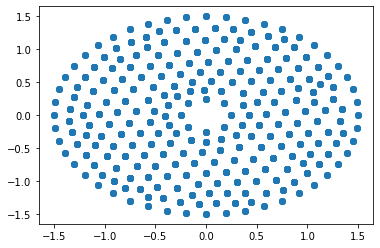

In [94]:
tri_points, tri_indices = read_points(mesh, "surface", reverse=False)

Points array shape: (8, 2, 3)
Points array shape: (48, 2, 3)


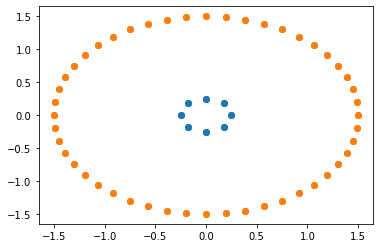

In [95]:
circ_in_points, circ_in_indices = read_points(mesh, "circle_in", reverse=False)
circ_out_points, circ_out_indices = read_points(mesh, "circle_out", reverse=True)

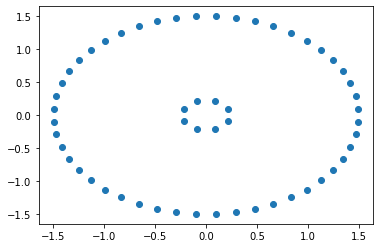

In [96]:
# Centroids by cell (ncells)
tri_centroids = tri_points.mean(axis=1, keepdims=False)

# Merge arrays of boundary cell-centers
n_circ_in_elts = circ_in_points.shape[0]
n_circ_out_elts = circ_out_points.shape[0]
bdry_points = np.concatenate([circ_in_points, circ_out_points], axis=0)
bdry_edge_centers = bdry_points.mean(axis=1, keepdims=False)
plt.scatter(bdry_edge_centers[:,0], bdry_edge_centers[:,1])


In [97]:
''' Compute boundary membership of cells '''
# IDs of nodes that lie on the circular boundary
node_id_circ_in = np.unique(circ_in_indices.ravel())
node_id_circ_out = np.unique(circ_out_indices.ravel())

# Compute boolean array showing which cell ID is on the boundaries
is_cell_on_bdry_circ_in = np.empty((tri_indices.shape[0]), dtype=bool)
is_cell_on_bdry_circ_out = np.empty((tri_indices.shape[0]), dtype=bool)
for i in range(tri_indices.shape[0]):
  # Check membership of any bdry node along axis 1
  if len(np.intersect1d(tri_indices[i,:], node_id_circ_in)) == 0:
    is_cell_on_bdry_circ_in[i] = False
  else:
    is_cell_on_bdry_circ_in[i] = True
  # Check membership of any bdry node along axis 1
  if len(np.intersect1d(tri_indices[i,:], node_id_circ_out)) == 0:
    is_cell_on_bdry_circ_out[i] = False
  else:
    is_cell_on_bdry_circ_out[i] = True

In [98]:
''' Compute tri-element areas '''
tri_areas = 0.5 * np.abs(np.cross(tri_points[:,2,:] - tri_points[:,0,:],
         tri_points[:,1,:] - tri_points[:,0,:])[:,-1])
tri_areas.sum(), np.pi*(1.5**2 - 0.25**2)

(6.871637684586148, 6.872233929727672)

Laplace fundamental solution

In [99]:
def G(r):
  ''' Laplace fundamental solution '''
  return -1 / (4.0 * np.pi) * np.log(np.einsum("...i, ...i -> ...", r, r))

def G_vec(r):
  ''' Vectorized Laplace fundamental solution '''
  r2 = np.einsum("...i, ...i -> ...", r, r)
  np.log(r2, out=r2, where=r2>0)
  return r2 / (-4.0 * np.pi)

def dGdn(r, nhat):
  ''' d/dn of Laplace fundamental solution '''
  rnorm = np.linalg.norm(r,axis=-1)
  drdn = np.einsum("...i, ...i -> ...", -nhat, r/rnorm)
  return -1 / (2.0 * np.pi * rnorm) * drdn

def dGdn_vec(r, nhat):
  ''' Vectorized d/dn of Laplace fundamental solution '''
  r2 = np.einsum("...i, ...i -> ...", r, r)
  np.divide(np.einsum("...i, ...i -> ...", -nhat, r),
            -2.0 * np.pi * r2, out=r2, where=r2>0)
  return r2

def rotate_vec(v):
  ''' Rotate vector counterclockwise 90 degrees along last axis '''
  w = v.copy()
  w[...,[1,0]] = w[...,[0,1]]
  w[...,0] *= -1
  return w

Area-integration of Laplace fundamental solution

In [100]:
def int_r_G(R):
  ''' r * G partially integrated in r from 0 to r = R '''
  return (-1 / (2.0 * np.pi)) * R * R * (2 * np.log(R) - 1.0) / 4.0

def integrateG_ws(x_vertices, N_per_side=3, debug=False, method=2):
  ''' Integrates G in triangle including weak singularity.
  Polar coordinate integration dr dtheta. Analytic integration in
  dr direction, numerical integration in theta(r).
  
  Due to curvature approximation of the dtheta element, max expected order is 2.
  '''
  theta_tot = 0
  I = 0
  # Compute vertex coordinates relative to centroid
  x_shift = x_vertices - x_vertices.mean(axis=0)
  for _ii in range(3):
    # Compute vector representing edge of triangle
    _dx = x_shift[_ii] - x_shift[_ii-1]
    for _jj in range(N_per_side):
      # Trap integration along this edge
      interval_start  = x_shift[_ii-1] + (_jj) * _dx / N_per_side
      interval_center = x_shift[_ii-1] + (_jj + 0.5) * _dx / N_per_side
      interval_end    = x_shift[_ii-1] + (_jj + 1) * _dx / N_per_side
      r_start  = np.linalg.norm(interval_start)
      r_center = np.linalg.norm(interval_center)
      r_end    = np.linalg.norm(interval_end)
      theta_start = np.arctan2(interval_start[1], interval_start[0])
      theta_end   = np.arctan2(interval_end[1], interval_end[0])
      dtheta = np.mod(theta_end - theta_start, 2*np.pi)
      if method==3:
        dI = (int_r_G(r_start) + 4 * int_r_G(r_center) + int_r_G(r_end)) * dtheta / 6.0
      elif method==2:
        dI = (0.5 * int_r_G(r_start) + 0.5 * int_r_G(r_end)) * dtheta
      else:
        raise ValueError("Input param `method` options: {2, 3}.")
      I += dI
      if debug:
        print(dtheta, dI)
        theta_tot += dtheta
        plt.plot(interval_center[0], interval_center[1], '.')

  if debug:
    plt.plot(0, 0, 'ko')
    print(f"Total angle: {theta_tot/np.pi} * pi")
  return I

In [101]:
from dataclasses import dataclass

@dataclass
class MeshGeom:
  ''' Data struct for mesh geometry '''
  # Indices for tri vertices (ntris, 3,)
  tri_indices: np.array
  # 3D coordinates for tri vertices (ntris, 3, ndim=3,)
  tri_points: np.array
  # 3D coordinates for tri centroids (ntris, ndim=3,)
  tri_centroids: np.array
  # Area of tris (ntris,)
  tri_areas: np.array

  # Indices for inner boundary segments (n_in, 2,)
  circ_in_indices: np.array
  # 3D coordinates for inner boundary segment endpoints (n_in, 2, 3)
  circ_in_points: np.array
  # Indices for outer boundary segments (n_out, 2,)
  circ_out_indices: np.array
  # 3D coordinates for outer boundary segment endpoints (n_out, 2, 3)
  circ_out_points: np.array
  # Indices for all boundary segments (n_in + n_out, 2, 3)
  bdry_points: np.array
  # 3D coordinates for all boundary center points (n_in + n_out, 3)
  bdry_edge_centers: np.array

  # Boolean checking if tri is on inner boundary (ntris,)
  is_cell_on_bdry_circ_in: np.array
  # Boolean checking if tri is on outer boundary (ntris,)
  is_cell_on_bdry_circ_out: np.array
  
  # Counts
  n_circ_in_elts: np.array
  n_circ_out_elts: np.array
  n_nodes: np.array
  n_cells: np.array
  
  # Original mesh object
  mesh: object

In [102]:
geom = MeshGeom(
  tri_indices,
  tri_points,
  tri_centroids,
  tri_areas,
  circ_in_indices,
  circ_in_points,
  circ_out_indices,
  circ_out_points,
  bdry_points,
  bdry_edge_centers,
  is_cell_on_bdry_circ_in,
  is_cell_on_bdry_circ_out,
  n_circ_in_elts,
  n_circ_out_elts,
  n_nodes,
  n_cells,
  mesh)

In [103]:
np.concatenate((geom.bdry_edge_centers[:,0:2],
                            geom.tri_centroids[:,0:2],), axis=0).shape

(518, 2)

In [104]:
geom.tri_areas.shape

(462,)

In [105]:
class ops():
  def __init__(self, geom, N_per_side=10, plot_normal_vecs=False,):
    # Geometry processing
    self.n_cells = tri_centroids.shape[0]
    self.n_bdry_node = geom.n_circ_in_elts + geom.n_circ_out_elts 
    self.N = n_cells + self.n_bdry_node
    self.geom = geom
    # Assemble global x points as list (N, 2)
    self.x_nodes = np.concatenate((geom.bdry_edge_centers[:,0:2],
                            geom.tri_centroids[:,0:2],), axis=0)

    # Set integration opption
    self.N_per_side = 10

    # Directed boundary element dg (dgamma) with shape (n_bdry_node, 2,)
    self.dg = (geom.bdry_points[:,1,0:2] - geom.bdry_points[:,0,0:2])
    # Measure of each boundary element with shape (n_bdry_node,) 
    self.dg_size = np.linalg.norm(self.dg, axis=-1)
    # Compute outward normal unit vectors with shape (n_bdry_node, 2,)
    self.dn = rotate_vec(self.dg)
    np.divide(self.dn, np.linalg.norm(self.dn, axis=-1, keepdims=True),
              out=self.dn) 
    
    self.compute_di_singular()

    # Option to plot normal vectors
    if plot_normal_vecs:
      for j in range(self.n_bdry_node):
        plt.arrow(geom.bdry_edge_centers[j,0], geom.bdry_edge_centers[j,1],
                  self.dn[j,0], self.dn[j,1], head_width=0.06)
    
  def compute_di_singular(self):
    ''' Compute singular part of domain integral '''
    # Shift vertex coordinates relative to centroid (n_cells, 3, 2,)
    x_shift = (self.geom.tri_points[:,:,0:2]
               - self.geom.tri_points[:,:,0:2].mean(axis=1, keepdims=True))
    # Compute vectors representing triangle edges
    _dx = x_shift[:,[1,2,0],:] - x_shift
    # Set vector of variables in [0, 1] parametrizing distance along edge
    xi = np.expand_dims(
      np.linspace(0, 1, self.N_per_side, endpoint=False) / self.N_per_side,
      axis=(1,2,3))
    # Compute interval start points with shape (N_per_side, n_cells, 3, 2)
    interval_start = x_shift + xi * _dx
    # Compute interval end points with shape (N_per_side, n_cells, 3, 2)
    interval_end = x_shift + (xi + 1/self.N_per_side) * _dx
    # Convert interval endpoints to (r, theta)
    r_start = np.linalg.norm(interval_start, axis=-1)
    r_end = np.linalg.norm(interval_end, axis=-1)
    theta_start = np.arctan2(interval_start[...,1], interval_start[...,0])
    theta_end = np.arctan2(interval_end[...,1], interval_end[...,0])
    # Compute dtheta, wrapping to [0, 2*pi]
    dtheta = np.mod(theta_end - theta_start, 2*np.pi)
    # Compute second-order quadrature of weakly singular part as vector of
    # size (n_cells,) into bottom part of M (tall matrix; bottom part will become
    # block diagonal of larger square matrix)
    self.di_singular = np.einsum(
      "i...k, i...k -> ...",
      0.5 * int_r_G(r_start) + 0.5 * int_r_G(r_end), dtheta)

  def L(self, u, dt, theta=1.0):
    ''' Compute LHS matrix as linear transformation '''

    beta_d = 1.0

    u = u.squeeze()

    # Allocate output and temp vectors
    out = np.zeros_like(u)
    temp = u.copy()
    # Apply diagonal mass part, signed for the boundary term
    temp *= np.concatenate((-self.dg_size, self.geom.tri_areas/dt))

    # Multiply boundary part of u
    for i in range(self.N):
      out[i] = np.dot(
        G_vec(self.x_nodes[i,:] - self.geom.bdry_edge_centers[:,0:2]),
        temp[:self.n_bdry_node])
      
      out[i] += np.dot(
        G_vec(self.x_nodes[i,:] - self.geom.tri_centroids[:,0:2]),
        temp[self.n_bdry_node:])

    def G_singular_1D(r):
      ''' Singular part integrated in 1D '''
      return 2 * (-1 / (2.0 * np.pi)) * (r * np.log(r) - r)

    # Add singular part elementwise multiplying u
    out += np.concatenate((-G_singular_1D(self.dg_size/2),
                           self.di_singular/dt + beta_d * theta)) * u
    
    return out

  def f(self, u, u_bdry, dt, theta=1.0):
    ''' Compute RHS '''
    beta_b = 0.5
    beta_d = 1.0
    
    u = u.squeeze()
    u_bdry = u_bdry.squeeze()

    out = np.zeros_like(u)

    # Boundary data dependent part
    for i in range(self.N):
      out[i] = np.dot(
        -dGdn_vec(self.x_nodes[i,:] - bdry_edge_centers[:,0:2], self.dn),
        u_bdry * self.dg_size) 
    out[:self.n_bdry_node] -= beta_b * u_bdry

    P1 = out.copy()
    
    # Apply diagonal mass part, signed for the boundary term
    temp = u.copy()
    temp *= np.concatenate((0.0 * self.dg_size, self.geom.tri_areas/dt))

    # Domain dependent part
    for i in range(self.N):
      out[i] += np.dot(
        G_vec(self.x_nodes[i,:] - self.geom.tri_centroids[:,0:2]),
        temp[self.n_bdry_node:])

    out[self.n_bdry_node:] += (self.di_singular/dt
                               + beta_d * (theta - 1.0)) * u[self.n_bdry_node:]
      
    P2 = out - P1

    return P1, P2, out
    
  # # Full-sized operators
  # C_op = -C.copy()
  # C_op[:n_bdry_node,:] -= beta_b * np.eye(n_bdry_node)
  # D_op = (M/dt).copy()
  # D_op[n_bdry_node:,:] += beta_d * (theta - 1.0) * np.eye(n_cells)
  # D_op = np.concatenate((np.zeros((N, n_bdry_node)), D_op), axis=1)
  

In [106]:
# Node counting
n_cells = tri_centroids.shape[0]
n_bdry_node = bdry_edge_centers.shape[0]
N = n_cells + n_bdry_node

def assemble(plot_normal_vecs=False, N_per_side=10):
  K = np.zeros((N, n_bdry_node)) # Single-layer potential coefficient matrix (K @ du/dn)
  C = np.zeros((N, n_bdry_node)) # Double-layer potential coefficient matrix (dK/dn @ u)
  M = np.zeros((N, n_cells))     # Volume integral (dK/dt @ u)

  # Assemble global x points as list (bdry_centers, tri_centers)
  x_nodes = np.concatenate((bdry_edge_centers[:,0:2],
                            tri_centroids[:,0:2],), axis=0)
  
  ''' Compute boundary contributions

  Compute regular parts of operators K, C that multiply dudn and u respectively.
  Then compute singular part of K using explicit integration. Singular part
  of C is zero since dr/dn is zero on the boundary.

  To access the jth boundary element, use bdry_points[j,:,0:2] for the vertices
  and bdry_edge_centers[j,0:2] for the boundary center.
  '''
  # Matrix of all r-vectors with shape (n_bdry_nodes + n_cells, n_bdry_nodes, 2)
  r_all = (x_nodes[:,np.newaxis,:] - bdry_edge_centers[np.newaxis,:,0:2])
  # Directed boundary element dg (dgamma) with shape (n_bdry_node, 2,)
  dg = (bdry_points[:,1,0:2] - bdry_points[:,0,0:2])
  # Measure of each boundary element with shape (n_bdry_node,) 
  dg_size_all = np.linalg.norm(dg, axis=-1)
  # Compute outward normal unit vectors with shape (n_bdry_node, 2,)
  dn_all = rotate_vec(dg)
  dn_all /= np.linalg.norm(dn_all, axis=-1)[:,np.newaxis]

  # Vectorized computation of K = G(r) * dgamma_j, operator for @ dudn
  K = G_vec(r_all) * dg_size_all
  # Vectorized computation of C = dG/dn(r) * dgamma_j, operator for @ u
  C = dGdn_vec(r_all, dn_all) * dg_size_all
  # Compute singular boundary integrals using exact integration around pole
  for i in range(n_bdry_node):
    r_eff = (dg_size_all[i]/2)
    K[i,i] = 2 * (-1 / (2.0 * np.pi)) * (r_eff * np.log(r_eff) - r_eff)

  # Option to plot normal vectors
  if plot_normal_vecs:
    for j in range(n_bdry_node):
      plt.arrow(bdry_edge_centers[j,0], bdry_edge_centers[j,1],
                dn_all[j,0], dn_all[j,1], head_width=0.06)

  ''' Compute volume contributions

  Compute regular parts of operator M multiplies u_interior.
  Then compute singular part of M using explicit integration in r, numerically
  integrating in angle theta. 

  To access the jth cell, use x_vertices[j,:,0:2] for the vertices
  and tri_centroids[j,0:2] for the boundary center.
  '''

  # Matrix of all r-vectors with shape (n_bdry_nodes + n_cells, n_cells, 2)
  r_all = (x_nodes[:,np.newaxis,:] - tri_centroids[np.newaxis,:,0:2])
  # Vectorized computation of M = G(r) * dOmega_j, operator for @ u_interior
  M = G_vec(r_all) * tri_areas

  # Shift vertex coordinates relative to centroid (n_cells, 3, 2,)
  x_shift = (tri_points[:,:,0:2] - tri_points[:,:,0:2].mean(axis=1, keepdims=True))
  # Compute vectors representing triangle edges
  _dx = x_shift[:,[1,2,0],:] - x_shift
  # Set vector of variables in [0, 1] parametrizing distance along edge
  xi = np.expand_dims(
    np.linspace(0, 1, N_per_side, endpoint=False) / N_per_side, axis=(1,2,3))
  # Compute interval start points with shape (N_per_side, n_cells, 3, 2)
  interval_start = x_shift + xi * _dx
  # Compute interval end points with shape (N_per_side, n_cells, 3, 2)
  interval_end = x_shift + (xi + 1/N_per_side) * _dx
  # Convert interval endpoints to (r, theta)
  r_start = np.linalg.norm(interval_start, axis=-1)
  r_end = np.linalg.norm(interval_end, axis=-1)
  theta_start = np.arctan2(interval_start[...,1], interval_start[...,0])
  theta_end = np.arctan2(interval_end[...,1], interval_end[...,0])
  # Compute dtheta, wrapping to [0, 2*pi]
  dtheta = np.mod(theta_end - theta_start, 2*np.pi)
  # Compute second-order quadrature of weakly singular part as vector of
  # size (n_cells,) into bottom part of M (tall matrix; bottom part will become
  # block diagonal of larger square matrix)
  M[np.arange(0,n_cells) + n_bdry_node, np.arange(0,n_cells)] = np.einsum(
    "i...k, i...k -> ...",
    0.5 * int_r_G(r_start) + 0.5 * int_r_G(r_end), dtheta)

  return K, C, M

### Annulus setup

Blue: approximation, red: numerical Bessel-sum root


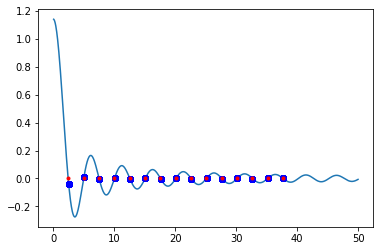

In [107]:
''' Compute eigenfunctions in 2D annulus Dirichlet problem '''
# Determinant equation for system of coefficients to J0, Y0 in eigenfunction
j0, y0, j1, y1 = scipy.special.j0, scipy.special.y0, scipy.special.j1, scipy.special.y1

def det(m, a, b):
  ''' Determinant of matrix M in
    [0, 0]^T = M(m) @ [c_J, c_Y]^T,
  which is the eigenfunction condition for a Dirichlet problem in a 2D annulus.
  The general solution is a linear combination
    c_J * J0(r) + c_Y * Y0(r),
  and the linear system above admits non-trivial solutions when det M == 0.
  '''
  return j0(m*a) * y0(m*b) - j0(m*b) * y0(m*a)

def det_dm(m, a, b):
  ''' Derivative of function `det` with respect to argument m. '''
  return -(
    a * j1(m*a) * y0(m*b)
    + b * j0(m*a) * y1(m*b)
    - b * j1(m*b) * y0(m*a)
    - a * j0(m*b) * y1(m*a)
  )

N_roots = 15

# Approximate with cos(0.5 * m * (b-a)) and estimate roots of det with pi / (b-a)
m_guesses = np.arange(1,N_roots+1) * np.pi / (b - a)
roots = np.zeros_like(m_guesses)

for i, n in enumerate(m_guesses):
  roots[i] = scipy.optimize.fsolve(
    lambda m: det(m, a, b),
    m_guesses[i],
    fprime=lambda m: det_dm(m, a, b))

m_test_range = np.linspace(0,50,1001)[1:]
plt.plot(m_test_range, det(m_test_range, a, b))
# plt.plot(m_test_range, np.cos(m_test_range * (b-a) / 2 ))
for k in range(N_roots):
  plt.plot(m_guesses, det(m_guesses, a, b), 'ob')

plt.plot(roots, det(roots, a, b), '.r')
print("Blue: approximation, red: numerical Bessel-sum root")

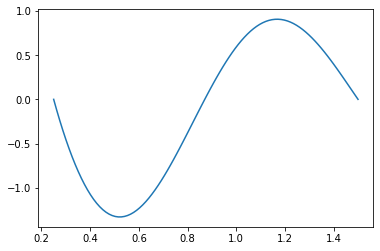

In [108]:
''' Plot sample eigenfunction constructed using Bessels, setting C_j = 1.0 '''
_r = roots[1]
cj = 1.0
cy = - cj * j0 (_r * a) / y0(_r * a)

r_sample_range = np.linspace(a, b, 100)
summed_sample = cj * j0 (_r * r_sample_range) + cy * y0(_r * r_sample_range)
plt.plot(r_sample_range, summed_sample)

Text(0.5, 1.0, 'Analytic solution with 1-eigenfunction initial condition')

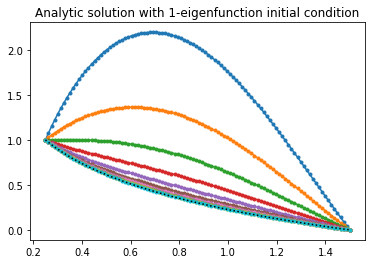

In [109]:
# Series solution for spherical shell heat conduction

def steady_term(r, t, a, b, dim=2):
  if dim == 2:
    return np.log(r / b) / np.log(a / b)
  elif dim == 3:
    return a / (a - b) * (1 - b / r)

def series_term(r, t, a, b, n, dim=2, alpha=1):
  if dim == 2:
    if n < 1 or n > roots.size:
      raise ValueError(f"n = {n} not valid. Need n = 1 to {roots.size} (or compute more roots).")
    eig = roots[n-1]
    # Compute coefficients using r = a boundary condition
    cj = 1.0
    cy = - cj * j0 (eig * a) / y0(eig * a)
    # Time-dependent factor, with diffusivity TODO: for other funtcions
    t_factor = np.exp(- alpha * eig * eig * t)
    # Space-dependent factor
    r_factor = cj * j0(eig * r) + cy * y0(eig * r)
    return t_factor * r_factor
  elif dim == 3: 
    # Array of eigenvalues
    eig = n * np.pi / (b - a)
    # Return eigenfunction term with nondimensionalizing scaling (b - a) / 2
    return (b - a) / 2 * np.exp(-eig*eig * t) * np.sin(eig*(r - a)) / r

def steady_ddr(r, t, a, b, dim=2):
  if dim == 2:
    return 1 / r / np.log(a / b)
  elif dim == 3:
    return  a * b / (a - b) / (r * r)

def series_ddr(r, t, a, b, n, dim=2, alpha=1.0):
  if dim == 2:
    if n < 1 or n > roots.size:
      raise ValueError(f"n = {n} not valid. Need n = 1 to {roots.size} (or compute more roots).")
    eig = roots[n-1]
    # Compute coefficients using r = a boundary condition
    cj = 1.0
    cy = - cj * j0 (eig * a) / y0(eig * a)
    # Time-dependent factor, with diffusivity TODO: for other funtcions
    t_factor = np.exp(- alpha * eig * eig * t)
    # Space-dependent factor
    r_factor = -eig * (cj * j1(eig * r) + cy * y1(eig * r))
    return t_factor * r_factor
  elif dim == 3:
    # Array of eigenvalues
    eig = n * np.pi / (b - a)
    # Return eigenfunction term with nondimensionalizing scaling (b - a) / 2
    return (b - a) / 2 * np.exp(-eig*eig * t) * (
        eig * np.cos(eig*(r - a)) / r
        - np.sin(eig*(r - a)) / (r*r)
      )

a = 0.25
b = 1.5
t_final = 1.0
for t in np.linspace(0, t_final, 10):
  r_test_range = np.linspace(a, b, 100)
  T_test = steady_term(r_test_range, t, a, b) + series_term(r_test_range, t, a, b, 1)
  plt.plot(r_test_range, T_test, '.-')

plt.plot(r_test_range, steady_term(r_test_range, t, a, b), 'k:')
plt.title("Analytic solution with 1-eigenfunction initial condition")

## Code

Assemble the full-memory matrix to compare with the operator-based implementation.

In [110]:
K, C, M = assemble()

In [111]:
''' Matrix build '''

# Numerical method parameters
dt = 1e-2
theta = 1.0


In [112]:
op = ops(geom)

In [113]:
# Set boundary conditions
u_bdry = np.zeros((op.n_bdry_node,1))
# Set Dirichlet data on the inner boundary (access using concatenation order)
u_bdry[0:node_id_circ_in.size] = 1.0

# Set initial conditions
r_eval = np.linalg.norm(tri_centroids, axis=1)
# Evaluate data in cell
IC_cell_data = steady_term(r_eval, 0.0, a, b) + series_term(r_eval, 0.0, a, b, 1)
# Evaluate Neumann data on boundary
IC_bdry_circ_in_data = -(
    steady_ddr(a, 0.0, a, b) + series_ddr(a, 0.0, a, b, 1)
  ) * np.ones((node_id_circ_in.shape))
IC_bdry_circ_out_data = (
    steady_ddr(b, 0.0, a, b) + series_ddr(b, 0.0, a, b, 1)
  ) * np.ones((node_id_circ_out.shape))

# Fill data into mixed vector
u0 = np.zeros((op.N, ))
u0[0:n_circ_in_elts] = IC_bdry_circ_in_data
u0[n_circ_in_elts:n_circ_in_elts+n_circ_out_elts] = IC_bdry_circ_out_data
u0[op.n_bdry_node:] = IC_cell_data
u0 = u0[:,np.newaxis]

In [114]:
N = op.N
# Fill L matrix naively
LR = np.zeros((N,N))
for i in range(N):
  ei = np.zeros((N,))
  ei[i] = 1.0
  LR[:,i] = op.L(ei, dt)

In [115]:
lu, piv = scipy.linalg.lu_factor(LR)

LHS matrix and mappings from previous timestep are dense


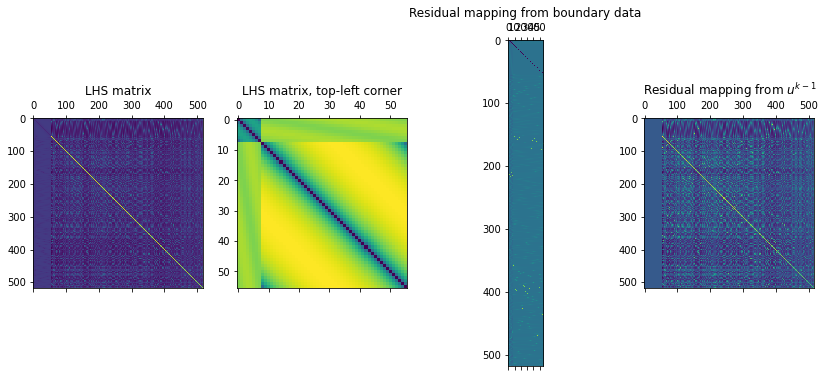

In [116]:
''' Matrix build '''

# Numerical method parameters
dt = 1e-2
theta = 1.0

beta_d = 1.0
beta_b = 0.5

L = np.concatenate((-K, M/dt), axis=1)
L[n_bdry_node:,n_bdry_node:] += beta_d * theta * np.eye(n_cells)

# Full-sized operators
C_op = -C.copy()
C_op[:n_bdry_node,:] -= beta_b * np.eye(n_bdry_node)
D_op = (M/dt).copy()
D_op[n_bdry_node:,:] += beta_d * (theta - 1.0) * np.eye(n_cells)
D_op = np.concatenate((np.zeros((N, n_bdry_node)), D_op), axis=1)

fig, ax = plt.subplots(1, 4, figsize=(14,6))
ax[0].matshow(L)
ax[0].set_title("LHS matrix")
ax[1].matshow(L[0:n_bdry_node, 0:n_bdry_node])
ax[1].set_title("LHS matrix, top-left corner")
ax[2].matshow(C_op)
ax[2].set_title("Residual mapping from boundary data")
ax[3].matshow(D_op)
ax[3].set_title("Residual mapping from $u^{k-1}$")

print("LHS matrix and mappings from previous timestep are dense")

In [117]:
''' Timestepping '''

u = u0.copy()

# Timestepping
N_t = 100

# v_hist = np.zeros((N_t, n_circ_elts,))
u_hist = np.zeros((N_t, *u0.shape,))

for i in range(N_t):
  # Solve equation
  #   L @ q^{k} == CG @ u_Gamma + DG @ q^{k-1}
  # u = np.linalg.solve(L, C_op @ u_bdry + D_op @ u)
  u = scipy.linalg.lu_solve((lu, piv), op.f(u, u_bdry, dt, theta)[2])
  # v_hist[i,:] = u[:n_circ_elts].ravel()
  u_hist[i,...] = u[:,np.newaxis]
# plt.plot(u)

1.135693197987185

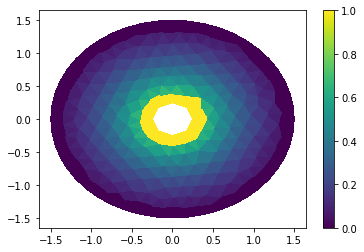

In [118]:
# Extract du/dn, u_interior (u_Omega)
n_bdry_node = op.n_bdry_node
v = u[:n_bdry_node]
u_int = u[n_bdry_node:]

u_show = u_int.copy()
u_show[np.where(is_cell_on_bdry_circ_in)] = 1.0
u_show[np.where(is_cell_on_bdry_circ_out)] = 0.0

triangulation = matplotlib.tri.Triangulation(mesh.points[:,0], mesh.points[:,1], tri_indices)
plt.tripcolor(triangulation, u_show.squeeze())
plt.colorbar()
u_int.max()

In [119]:
''' Plot along a line probe '''
trifinder = triangulation.get_trifinder()

probe_line = np.linspace(0.25+.01, 1.5-.01, 100)
pick_indices = [int(trifinder(x, 0.0)) for x in probe_line]
u_along_line = u_int[pick_indices]

u_int_hist = u_hist[:,n_bdry_node:,0]
u_hist_along_line = u_int_hist[:,pick_indices]

Text(0.5, 1.0, 'Initial condition')

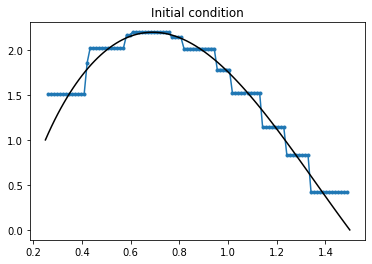

In [120]:
u0_int = u0[n_bdry_node:]
plt.plot(probe_line, u0_int[pick_indices], '.-')
plt.plot(r_test_range, steady_term(r_test_range, 0, a, b) + series_term(r_test_range, 0, a, b, 1), 'k-')
plt.title("Initial condition")

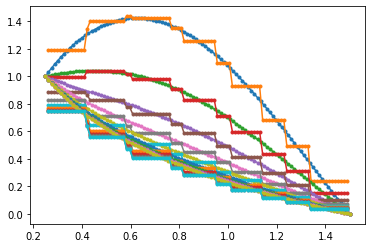

In [121]:
t_plot_vec = 10*(dt + dt*np.arange(0,10))

for i, t in enumerate(t_plot_vec):
  # Compute constructed analytic solution
  r_test_range = np.linspace(a, b, 100)
  T_test = steady_term(r_test_range, t, a, b) + series_term(r_test_range, t, a, b, 1)
  # Plot analytic
  plt.plot(r_test_range, T_test, '.-')
  # Plot numerical
  plt.plot(probe_line, u_hist_along_line[10*i+9,:], '.-')

# plt.plot(r_test_range, steady_term(r_test_range, t, a, b), 'k:')

Text(0, 0.5, '$\\partial u/\\partial r$')

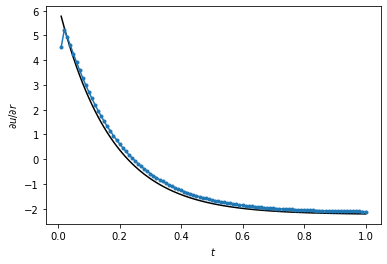

In [122]:
''' Compare normal gradient value at boundary '''

# Extract gradients at inner circle boundary
dudr_hist = u_hist[:,:n_circ_in_elts,0]
# dudr_numerical_steady = -u_s[:n_circ_in_elts].squeeze()

t_plot_range = (dt + dt*np.arange(0,N_t))
dudr_exact = steady_ddr(a, 0.0, a, b, dim=2) + series_ddr(a, t_plot_range, a, b, 1, dim=2, alpha=1.0)
plt.plot(t_plot_range, dudr_exact, 'k-')
plt.plot(t_plot_range, -dudr_hist.mean(axis=1), '.-')
plt.xlabel("$t$")
plt.ylabel("$\partial u/\partial r$")